# SpinLab HYSCORE Processing Tutorial

This notebook demonstrates a practical workflow for processing 2D HYSCORE data in SpinLab.

## Tutorial Goals

In this notebook we will:

- Load a 2D HYSCORE dataset
- Inspect `t1` and `t2` dimensions
- Visualize the time-domain matrix
- Apply background correction and apodization in two dimensions
- Generate the 2D Fourier spectrum

## About SpinLab

SpinLab is a Python package for EPR and magnetic resonance data processing.

It provides tools for:

- Data loading
- Signal processing
- Visualization
- Spectral analysis
- Workflow automation

## Loading HYSCORE Data

The next section loads an example HYSCORE dataset. HYSCORE data is processed over both `t1` and `t2`, so most operations are applied independently along both dimensions.

In [33]:
# Load example HYSCORE data

import spinlab as sl
import numpy as np
import matplotlib.pyplot as plt

path = '../data/specman_hyscore.exp'
path = '../data/xepr_032_HYSCORE 32ns.DTA'
data = sl.load(path)

print(data)


values:
	256 x 256 ndarray (complex128)
dims:
	['t2', 't1']
coords:
	array([ 400.,  416.,  432., ..., 4448., 4464., 4480.], shape=(256,))
	array([ 400.,  416.,  432., ..., 4448., 4464., 4480.], shape=(256,))
attrs:
	'data_dim': 1
	'x_unit': 'ns'
	'y_unit': 'ns'
	'frequency': 9.720518
	'power': 0.4743
	+9 attrs


## Inspecting the Dataset

Once the data is loaded, we can inspect:

- Dimensions
- Axes
- Metadata
- Signal values

In [34]:
# Inspect dimensions

print('Dimensions:', data.dims)
print('Coordinates:')
print(data.coords)

# convert axes to microseconds
data.coords['t1'] /= 1e3
data.coords['t2'] /= 1e3

t1 = data.coords['t1']
t2 = data.coords['t2']

print('t1 (us):', t1)
print('t2 (us):', t2)


Dimensions: ['t2', 't1']
Coordinates:
dims:
['t2', 't1']
coords:
[array([ 400.,  416.,  432., ..., 4448., 4464., 4480.], shape=(256,)), array([ 400.,  416.,  432., ..., 4448., 4464., 4480.], shape=(256,))]
t1 (us): [0.4   0.416 0.432 ... 4.448 4.464 4.48 ]
t2 (us): [0.4   0.416 0.432 ... 4.448 4.464 4.48 ]


## Plotting the Time-Domain Matrix

The raw HYSCORE experiment is a 2D time-domain dataset indexed by `t1` and `t2`.

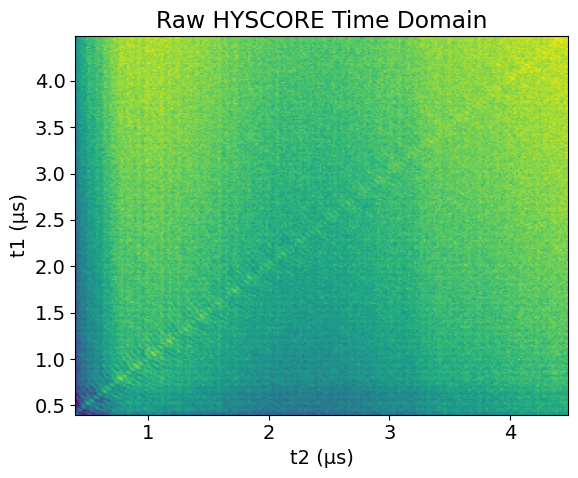

In [35]:
plt.rcParams['font.family'] = 'DejaVu Sans'

plt.figure(figsize=(6,5))
sl.imshow(data.real)
plt.xlabel('t2 (µs)')
plt.ylabel('t1 (µs)')
plt.title('Raw HYSCORE Time Domain')
plt.tight_layout()
plt.show()


## 2D Processing

For HYSCORE, the same operations are generally applied along both dimensions before performing a 2D Fourier transform.

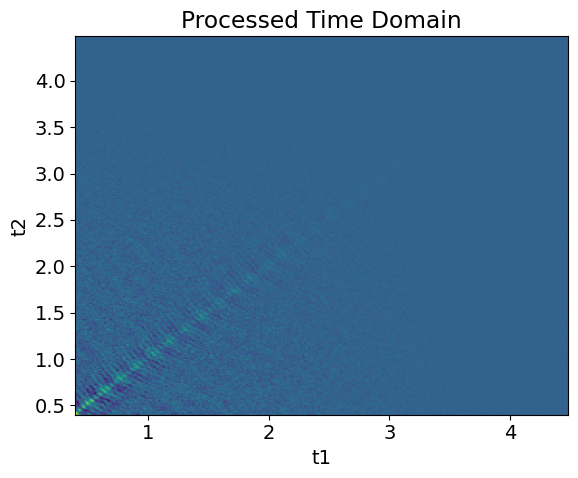

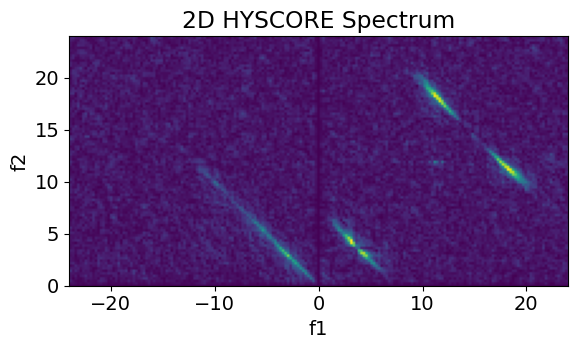

In [36]:
# HYSCORE processing

proc = data.real.copy()

# background correction on both dimensions
proc = proc - sl.background(proc, dim='t1', deg=2)
proc = proc - sl.background(proc, dim='t2', deg=2)

# normalize
proc /= np.max(np.abs(proc.values))

# apodization along both dimensions
proc = sl.apodize(proc, dim='t1', kind='hamming')
proc = sl.apodize(proc, dim='t2', kind='hamming')

plt.figure(figsize=(6,5))
sl.imshow(proc)
plt.title('Processed Time Domain')
plt.tight_layout()

# 2D FFT
spec = sl.fourier_transform(proc, dim='t1', convert_to_ppm = False)
spec = sl.fourier_transform(spec, dim='t2', convert_to_ppm = False)

plt.figure(figsize=(6,5))
sl.imshow(np.abs(spec), aspect = 'equal')
plt.title('2D HYSCORE Spectrum')
plt.xlim(-24,24)
plt.ylim(0,24)
plt.tight_layout()
plt.show()


## Summary

This notebook showed a standard HYSCORE workflow:

- Loading 2D data
- Inspecting `t1` and `t2`
- Applying processing along both dimensions
- Producing a 2D frequency-domain spectrum

You can extend this workflow with quadrant selection, symmetrization, and contour plotting.